In [27]:
import xarray as xr

ds_GFD_info = xr.open_dataset(
    "outputs/GreenSurge_Tonga_info_updated.nc",
    decode_times=False,
)
ds_GFD_info

<xarray.Dataset> Size: 230kB
Dimensions:                            (element_computation_index: 8657,
                                        triangle_forcing_nodes: 3,
                                        element_forcing_index: 16,
                                        node_forcing_index: 15,
                                        wind_direction_index: 8,
                                        node_cumputation_index: 4553,
                                        time_forcing_index: 4)
Coordinates:
  * element_computation_index          (element_computation_index) int32 35kB ...
    node_computation_longitude         (node_cumputation_index) float64 36kB ...
    node_computation_latitude          (node_cumputation_index) float64 36kB ...
  * node_cumputation_index             (node_cumputation_index) int32 18kB 0 ...
  * element_forcing_index              (element_forcing_index) int32 64B 0 .....
  * node_forcing_index                 (node_forcing_index) int32 60B 0 1 ... 14
  * wind_direction_index               (wind_direction_index) int32 32B 0 ... 7
  * time_forcing_index                 (time_forcing_index) float64 32B 0.0 ....
    triangle_nodes                     (triangle_forcing_nodes) int32 12B ...
Dimensions without coordinates: triangle_forcing_nodes
Data variables: (12/14)
    triangle_computation_connectivity  (element_computation_index, triangle_forcing_nodes) int32 104kB ...
    reference_date                     object 8B ...
    triangle_forcing_connectivity      (element_forcing_index, triangle_forcing_nodes) int32 192B ...
    node_forcing_longitude             (node_forcing_index) float64 120B ...
    node_forcing_latitude              (node_forcing_index) float64 120B ...
    wind_directions                    (wind_direction_index) int32 32B ...
    ...                                 ...
    simulation_duration_hours          int32 4B ...
    time_step_hours                    float64 8B ...
    wind_speed                         int32 4B ...
    eddy_viscosity                     int32 4B ...
    chezy_coefficient                  int32 4B ...
    forcing_time_step                  float64 8B ...
Attributes:
    title:        Hybrid Simulation Input Dataset
    description:  Structured dataset containing simulation parameters for hyb...
    created:      2025-10-14 15:49:21
    institution:  GeoOcean
    model:        GreenSurge
    source:       outputs/GreenSurge_Tonga_info.nc

In [29]:
TCname = "HAROLD2020"
figsize = (6, 5)
instant = [130, 160, 180]

xds_GS_wind =xr.open_dataset(f"outputs/GreenSurge_wind_setup_{TCname}.nc")

ds_WL_dynamic_WindSetUp_UV = xr.open_dataset(
    "assets/GreenSurge_Tonga_Harold2020_Validation.nc"
)


<div style="border: 1px solid #cce5ff; background-color: #e9f7fe; padding: 15px; border-radius: 6px; font-family: sans-serif;">
  <strong>🔹 Model validation</strong><br><br>

  The figures below show the maps of a given time and the swath maps of wind setup resulting from dynamic simulations with the Shallow Water Equation (SWE) model Delft3DFM (left panels) and from the GreenSurge aproach (right panels). These figures illustrate the importance of the wind setup in shallow water areas close to shore and de acuracy of the GreenSurge approach compared to dynamic simulations.
</div>

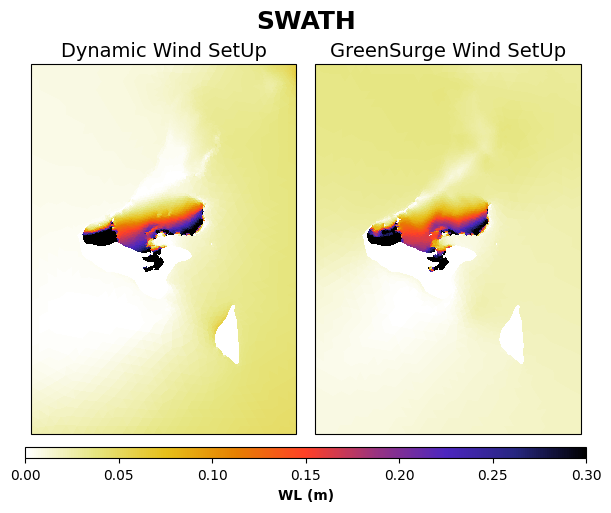

In [30]:
from bluemath_tk.additive.greensurge import plot_GS_vs_dynamic_windsetup_swath

plot_GS_vs_dynamic_windsetup_swath(
    ds_WL_GS_WindSetUp = xds_GS_wind, ds_WL_dynamic_WindSetUp = ds_WL_dynamic_WindSetUp_UV, ds_gfd_metadata = ds_GFD_info, vmin=0, vmax=0.3, figsize=figsize,
);

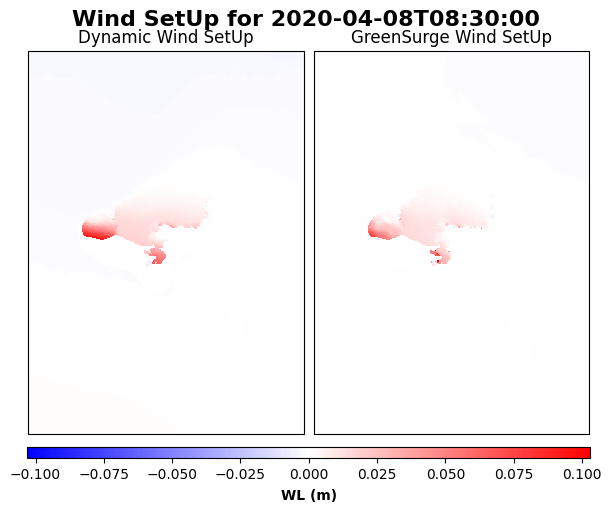

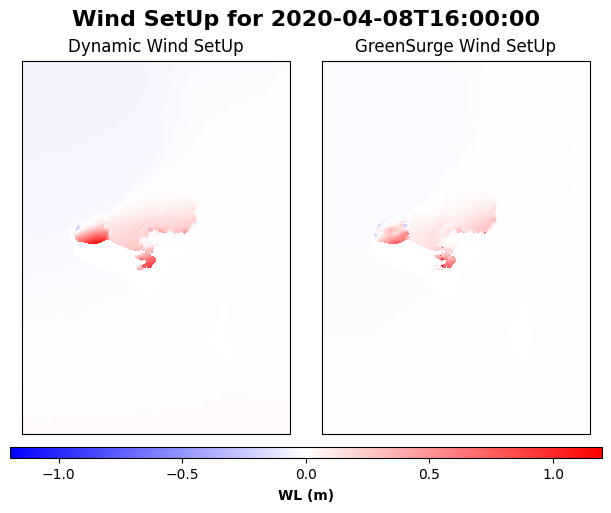

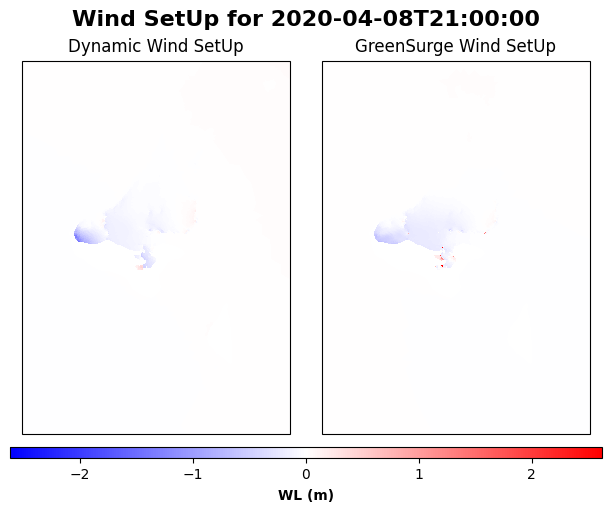

In [31]:
from bluemath_tk.additive.greensurge import plot_GS_vs_dynamic_windsetup

for i in instant:
    plot_GS_vs_dynamic_windsetup(
        ds_WL_GS_WindSetUp = xds_GS_wind,
        ds_WL_dynamic_WindSetUp = ds_WL_dynamic_WindSetUp_UV,
        ds_gfd_metadata = ds_GFD_info,
        time = ds_WL_dynamic_WindSetUp_UV.time[i].values,
        figsize = figsize,
    )

<div style="border: 1px solid #cce5ff; background-color: #e9f7fe; padding: 15px; border-radius: 6px; font-family: sans-serif;">
  <strong>🔹 Inverse Barometer</strong><br><br>

  The third stage for any TC event study consist of turning pressure differences into sea level rises and falls using IB methodology which take into account the correlation 1mb-1cm.
</div>


In [32]:
from bluemath_tk.additive.greensurge import pressure_to_IB

xds_vortex_GS = xr.open_dataset(
    f"outputs/GreenSurge_vortex_{TCname}.nc",
)

ds_WL_GS_IB = pressure_to_IB(xds_presure = xds_vortex_GS)

<div style="border: 1px solid #cce5ff; background-color: #e9f7fe; padding: 15px; border-radius: 6px; font-family: sans-serif;">
  <strong>🔹 Storm Surge</strong><br><br>

  Finally the fourth stage sums both components, the wind setup and the pressure-induced sea level changes, to obtain the storm surge.
  $$
  \eta_{SS} = \eta_{WindSetUp} + \eta_{IB}
  $$

</div>

<div style="border: 1px solid #cce5ff; background-color: #e9f7fe; padding: 15px; border-radius: 6px; font-family: sans-serif;">
  <strong>🔹 Model validation</strong><br><br>

  The panel below shows timeseries comparison of windsetup at three given locations. These figures illustrate the acuracy of Greensurge approach compared to dynamic simulations.
</div>

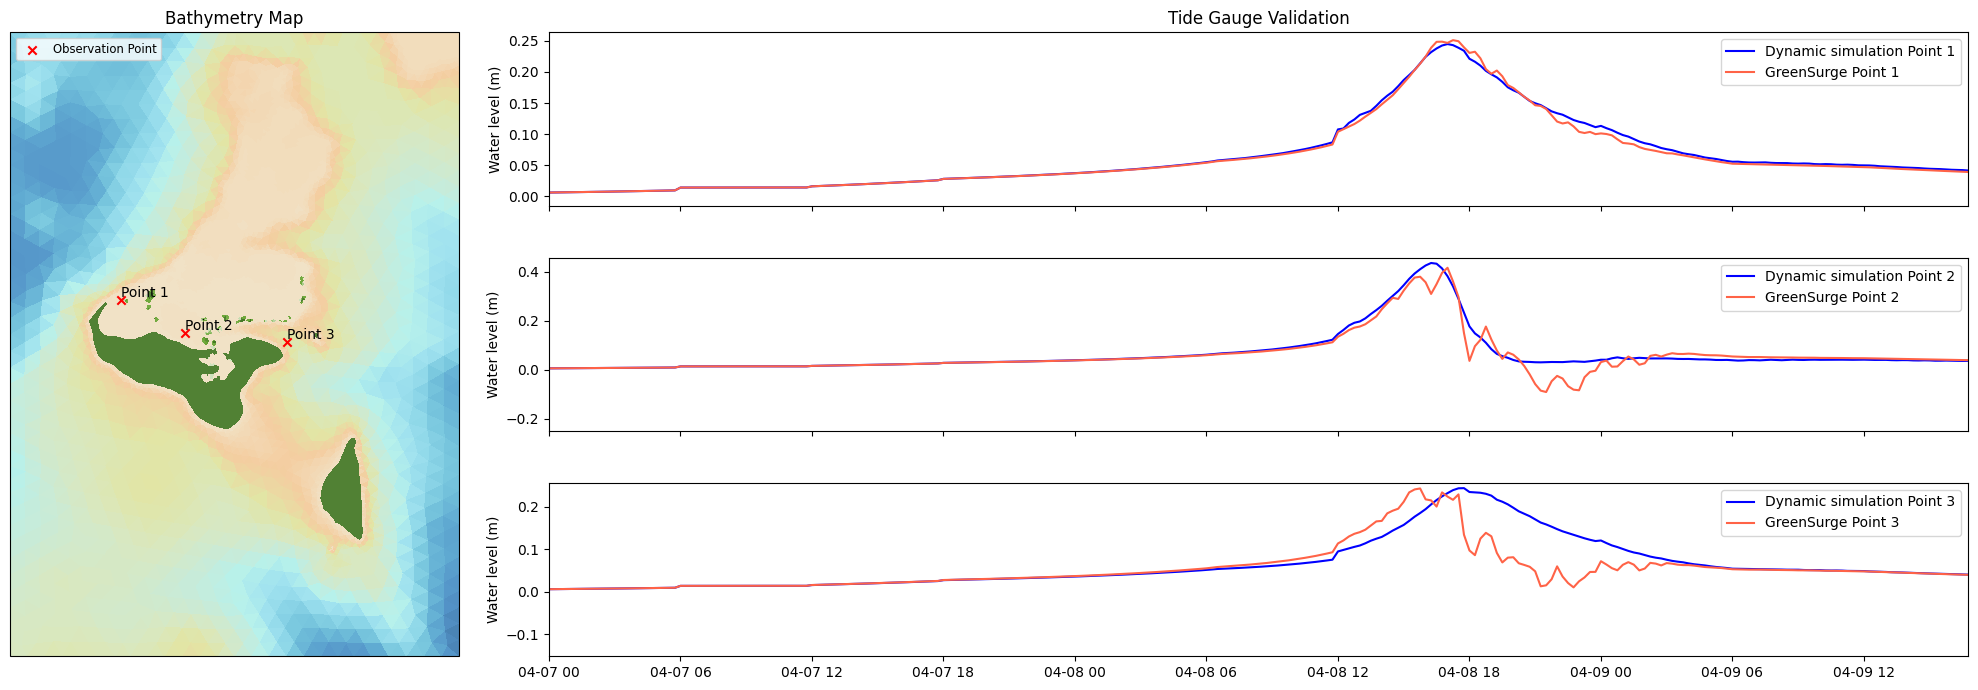

In [33]:
from bluemath_tk.additive.greensurge import plot_GS_validation_timeseries

plot_GS_validation_timeseries(
    ds_WL_GS_WindSetUp = xds_GS_wind,
    ds_WL_GS_IB = ds_WL_GS_IB,
    ds_WL_dynamic_WindSetUp = ds_WL_dynamic_WindSetUp_UV,
    ds_GFD_info = ds_GFD_info,
    lon_obs = [-175.30200513384034, -175.1955377589225, -175.02734416274885],
    lat_obs = [-21.059426057898943, -21.11369542021114, -21.129023408039775],
)